## bollinger_bands

Реализация индикатора Полосы Боллинджера,  отражающего текущие отклонения цены нефти марки BRENT

In [6]:
import pandas as pd
import os
import numpy as np
import pandas_datareader as pdr
import yfinance
import statistics

from matplotlib import pyplot as plt
from datetime import date

from finam import Exporter, Market, LookupComparator

%matplotlib inline

[*********************100%***********************]  1 of 1 completed


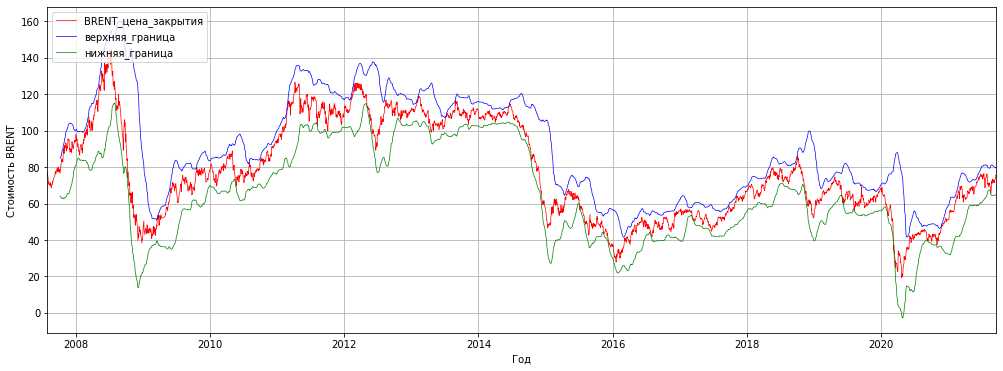

In [7]:
def SIGMA_BANDS(data, window):
    MA = data.Close.rolling(window=n).mean()
    SD = data.Close.rolling(window=n).std()
    data['UpperBB'] = MA + (3 * SD) 
    data['LowerBB'] = MA - (3 * SD)
    return data

n = 50
DATA_NAME = 'BRENT'
DATA = yfinance.download("BZ=F", start="1962-01-01", end="2021-09-17")

data = pd.DataFrame(DATA)
DATA_BBANDS = SIGMA_BANDS(data, n)
    
DATA_new = pd.concat([DATA_BBANDS.Close,DATA_BBANDS.UpperBB,DATA_BBANDS.LowerBB],axis=1)

fig, ax = plt.subplots(figsize=(17,6))

line1, = ax.plot(DATA_new['Close'],linewidth=0.7, color='red')
line1.set_label(DATA_NAME+'_цена_закрытия')
ax.legend(loc='upper left')

line2, = ax.plot(DATA_new['UpperBB'],linewidth=0.7, color='blue')
line2.set_label('верхняя_граница')
ax.legend(loc='upper left')

line3, = ax.plot(DATA_new['LowerBB'],linewidth=0.7, color='green')
line3.set_label('нижняя_граница')
ax.legend(loc='upper left')


plt.xlim(left=min(DATA_new.index).to_pydatetime().date(), right=
                       max(DATA_new.index).to_pydatetime().date())

ax.set_xlabel('Год')
ax.set_ylabel('Стоимость '+DATA_NAME)


plt.grid()
plt.show()